# Calibration

After running [`separate.ipynb`](./separate.ipynb), your next stop should be this notebook. This notebook is geared towards aligning the blinks detected by the "Mind Monitor" application, the EEG signal corresponding to that blink, and the blink estimated based on eye-tracking.

There are several ways to do this, but the idea is that we want to estiamte if there's a consistent way to detect the blinks based on the hardware, and then adjust the data to **align** them better. This thus removes any inconsistencies regarding timing, hopefully.

### Before we Start: Imports

In [140]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
from IPython.display import display, Markdown, Latex

pd.set_option('display.max_colwidth', None)   # Show full cell contents
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)          # Don't wrap lines
pd.set_option('display.float_format', '{:.0f}'.format)

### An Example: P1

Let's observe P1's data, which is stored in `src/data/P1/trials/`. Let's dive into the first trial's calibration stagge (`src/data/P1/trials/1/calibration/`) and interpret its relevant dataframes: 

In [88]:
_EX_DIR = './data/P1/trials/1/calibration/'

_eye = pd.read_csv(_EX_DIR+'eye.csv').drop(columns=['Unnamed: 0'])
_eeg_raw = pd.read_csv(_EX_DIR+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
_calibrations = pd.read_csv(_EX_DIR+'calibration.csv')
_cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])
display(_eye)

,unix_ms,rel_timestamp,frame,event,gaze_target_world_pos_x,gaze_target_world_pos_y,gaze_target_world_pos_z,gaze_target_screen_pos_x,gaze_target_screen_pos_y,gaze_target_screen_pos_z,gaze_direction_x,gaze_direction_y,gaze_direction_z,gaze_target_distance,gaze_target_name,head_target_world_pos_x,head_target_world_pos_y,head_target_world_pos_z,head_target_screen_pos_x,head_target_screen_pos_y,head_target_screen_pos_z,head_direction_x,head_direction_y,head_direction_z,head_position_x,head_position_y,head_position_z,head_target_distance,head_target_name,gaze_head_rel_direction_x,gaze_head_rel_direction_y,gaze_head_rel_direction_z,gaze_head_angle_diff
0,1758744734129,64,2391,NaN,-95,-0,4,905,762,95,-1,-0,0,100,NaN,-2,2,-4,720,792,7,-1,0,-0,5,2,-2,7,SouthBuildings_NoColliders,0,-0,1,18
1,1758744734156,64,2392,NaN,-95,-0,4,864,756,97,-1,-0,0,100,NaN,-4,2,-4,720,792,9,-1,0,-0,5,2,-2,9,SouthBuildings_NoColliders,0,-0,1,14
2,1758744734185,64,2393,Eye Hit,-50,1,1,829,759,53,-1,-0,0,54,SW_Tree_50,-9,2,-4,720,792,13,-1,0,-0,5,2,-2,13,SouthBuildings_NoColliders,0,-0,1,11
3,1758744734208,64,2394,Eye Hit,-51,2,1,800,758,55,-1,0,0,55,SW_Tree_50,-17,3,-4,720,792,21,-1,0,-0,5,2,-2,21,SouthBuildings_NoColliders,0,-0,1,9
4,1758744734250,64,2395,NaN,-95,2,1,750,756,100,-1,0,0,100,NaN,-95,9,-4,720,792,100,-1,0,-0,5,2,-2,100,NaN,0,-0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,1758744745598,76,2773,NaN,-96,0,2,729,736,100,-1,-0,0,100,NaN,-96,10,-0,720,792,100,-1,0,0,4,2,-2,100,NaN,0,-0,1,6
383,1758744745625,76,2774,NaN,-96,0,2,730,738,100,-1,-0,0,100,NaN,-96,10,-0,720,792,100,-1,0,0,4,2,-2,100,NaN,0,-0,1,5
384,1758744745653,76,2775,NaN,-96,0,2,730,738,100,-1,-0,0,100,NaN,-96,10,0,720,792,100,-1,0,0,4,2,-2,100,NaN,0,-0,1,5
385,1758744745680,76,2776,NaN,-96,0,2,729,736,100,-1,-0,0,100,NaN,-96,10,0,720,792,100,-1,0,0,4,2,-2,100,NaN,0,-0,1,6


Let's graph two pieces of data: the `gaze_head_angle_diff` feature inside of `_eye`, and the TP9/TP10 channels of the raw eeg in `_eeg_raw`:

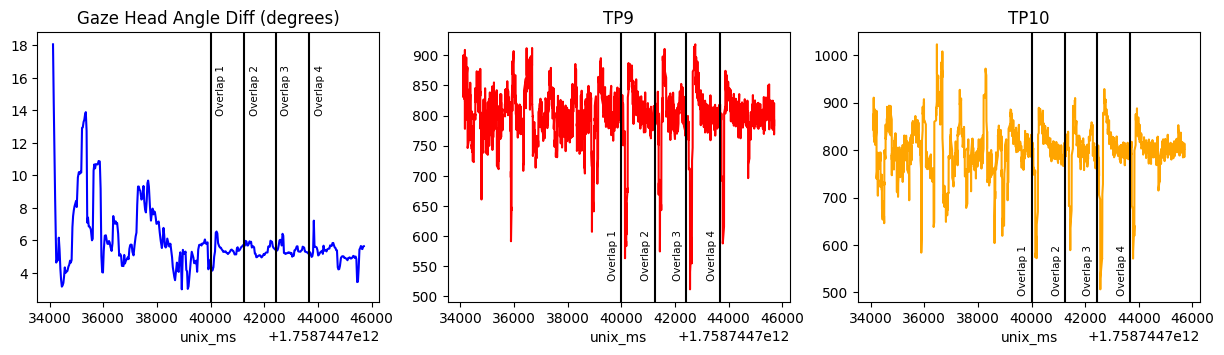

In [86]:
# Define the fig and axes. We'll create a 1x3 graph for this one.
fig, axes = plt.subplots(1,3, figsize=(15,3.5))

# First, render the `gaze_head_angle_diff` feature in the first column
_eye.plot(x='unix_ms', y='gaze_head_angle_diff', c='blue', ax=axes[0])
axes[0].set_title('Gaze Head Angle Diff (degrees)')
axes[0].legend().remove()

# Second, render TP9 in the second column
_eeg_raw.plot(x='unix_ms', y='TP9', c='red', ax=axes[1])
axes[1].set_title('TP9')
axes[1].legend().remove()

# Third, render TP10 in the third column
_eeg_raw.plot(x='unix_ms', y='TP10', c='orange', ax=axes[2])
axes[2].set_title('TP10')
axes[2].legend().remove()

# Fourth, render the calibration timestamps
for index, row in _cdf.iterrows():
    axes[0].axvline(x=row['unix_ms'], c='black')
    axes[0].text(row['unix_ms']+200, axes[0].get_ylim()[1]-2, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
    axes[1].axvline(x=row['unix_ms'], c='black')
    axes[1].text(row['unix_ms']-500, axes[1].get_ylim()[0]+120, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
    axes[2].axvline(x=row['unix_ms'], c='black')
    axes[2].text(row['unix_ms']-500, axes[2].get_ylim()[0]+120, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

plt.show()

There are some immediate standout things we should recognize:

1. There's **ALWAYS** a 5-sec beginning that doesn't actually mean anything. We can cull that out.
2. The EEG data is, naturally, going to have a higher sample rate (its' 255Hz vs an optimal 90Hz)
3. The data is completely noisy all around.

Let's smooth out the data and see if we get improved results. To achieve the smoothing, I'm using the popular [Savitzky-Golay Filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter), implemented via [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html). The filter is described further via [this video](https://www.youtube.com/watch?v=cY-OBfCnOxU). Let's create an **interactive** visualization that let's us adjust the filter params.

In [72]:
from scipy.signal import savgol_filter
from ipywidgets import interact, FloatSlider, IntSlider

x = _eye['unix_ms'].to_list()
y = _eye['gaze_head_angle_diff'].to_list()

def update_plot(window_length=22, polyorder=3):
    y_smoothed = savgol_filter(y, window_length=window_length, polyorder=polyorder, mode='nearest')

    plt.figure(figsize=(5,3.5))
    plt.plot(x, y, c='blue', alpha=0.5, label='raw')
    plt.plot(x, y_smoothed, c='green', label='smoothed')

    plt.show()

interact(
    update_plot,
    window_length = FloatSlider(value=22, min=10, max=100, step=0.1, description='Window Length'),
    polyorder = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order')
)

interactive(children=(FloatSlider(value=22.0, description='Window Length', min=10.0), IntSlider(value=3, descr…

<function __main__.update_plot(window_length=22, polyorder=3)>

The visualization above indicates that a window of `22` and a poly order of `3` is optimal for smoothing out the signal while also not removing too many features. What about the EEG data (specifically the `TP9` channel)?

In [ ]:
x = _eeg_raw['unix_ms'].to_list()
y = _eeg_raw['TP9'].to_list()

def update_plot(window_length=22, polyorder=3):
    y_smoothed = savgol_filter(y, window_length=window_length, polyorder=polyorder, mode='nearest')

    plt.figure(figsize=(5,3.5))
    plt.plot(x, y, c='blue', alpha=0.25, label='raw')
    plt.plot(x, y_smoothed, c='green', label='smoothed')

    plt.show()

interact(
    update_plot,
    window_length = FloatSlider(value=100, min=50, max=200, step=0.1, description='Window Length'),
    polyorder = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order')
)

interactive(children=(FloatSlider(value=100.0, description='Window Length', max=200.0, min=50.0), IntSlider(va…

<function __main__.update_plot(window_length=22, polyorder=3)>

This one is a bit harder to pinpoint the optimal parameters, because the data is inherently noisy. The same polyorder of `3` is common, but the window size appears to be somewhere between 100 and 200. We want to choose a dinow that won't let us lose TOO much about the signal features of the EEG data. For now, a window size of `125` might strike a fair balance.

Now, let's produce the same 3-column graph, but this time with the smoothed data.

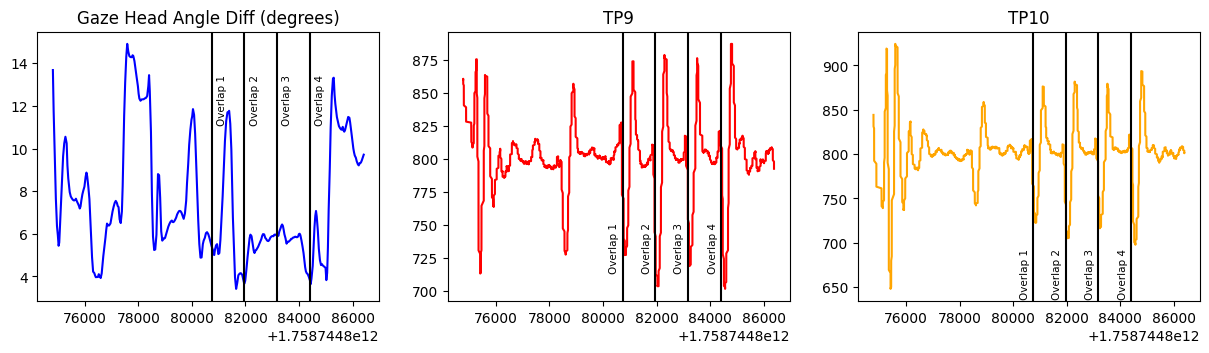

In [125]:
# Define the fig and axes. We'll create a 1x3 graph for this one.
fig, axes = plt.subplots(1,3, figsize=(15,3.5))

# Define a helper function to plot stuff
def plot_line(_x, _y, _ax, _title=None, _color='black', _marker='x', _alpha=1.0, _label=None):
    _ax.plot(_x, _y, c=_color, marker=_marker, alpha=_alpha, label=_label)
    if _title is not None: _ax.set_title(_title)

# Render our 3 columns
plot_line(
    _eye['unix_ms'].to_list(), 
    savgol_filter(_eye['gaze_head_angle_diff'].to_list(), window_length=10, polyorder=3, mode='nearest'), 
    axes[0],
    _color = 'blue',
    _title =  'Gaze Head Angle Diff (degrees)',
    _marker=None
)
plot_line(
    _eeg_raw['unix_ms'].to_list(),
    savgol_filter(_eeg_raw['TP9'].to_list(), window_length=125, polyorder=3, mode='nearest'),
    axes[1],
    _color = 'red',
    _title = 'TP9',
    _marker=None
)
plot_line(
    _eeg_raw['unix_ms'].to_list(),
    savgol_filter(_eeg_raw['TP10'].to_list(), window_length=125, polyorder=3, mode='nearest'),
    axes[2],
    _color = 'orange',
    _title = 'TP10',
    _marker=None
)

# Render the calibration timestamps
for index, row in _cdf.iterrows():
    axes[0].axvline(x=row['unix_ms'], c='black')
    axes[0].text(row['unix_ms']+200, axes[0].get_ylim()[1]-2, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
    axes[1].axvline(x=row['unix_ms'], c='black')
    axes[1].text(row['unix_ms']-500, axes[1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
    axes[2].axvline(x=row['unix_ms'], c='black')
    axes[2].text(row['unix_ms']-500, axes[2].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

plt.show()

These visualizations point a better picture of what's going on. Namely:

1. It'll be somewhat hard to determine when the user blinks, based purely on the angle difference between the head and the eyes.
2. The overlaps occur BEFORE there is a massive fluctuation in the EEG data. This implies that the massive fluctuation is representative of the actual blink, and that there's apparently a delay here.

This bets the question: is there a better way to identify blinks from eye data? Let's try looking at two other features: `gaze_target_screen_pos_x` and `gaze_target_screen_pos_y`. Assuming we need a [Savitzky-Golay Filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter), let's try testing it out.

In [113]:
# Extract the x and y's of our eye data
x = _eye['unix_ms'].to_list()
y1 = _eye['gaze_target_screen_pos_x'].to_list()
y2 = _eye['gaze_target_screen_pos_y'].to_list()

def update_plot(window_length=22, polyorder=3):
    y1_smoothed = savgol_filter(y1, window_length=window_length, polyorder=polyorder, mode='nearest')
    y2_smoothed = savgol_filter(y2, window_length=window_length, polyorder=polyorder, mode='nearest')

    # Render as two subplots instead
    fig, axes = plt.subplots(2, 1, figsize=(7.5,5))

    # Plot
    axes[0].plot(x, y1, alpha=0.25)
    axes[0].plot(x, y1_smoothed)
    axes[1].plot(x, y2, alpha=0.25)
    axes[1].plot(x, y2_smoothed)

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0].axvline(x=row['unix_ms'], c='black')
        axes[0].text(row['unix_ms']+200, axes[0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1].axvline(x=row['unix_ms'], c='black')
        axes[1].text(row['unix_ms']+200, axes[1].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    plt.tight_layout()
    plt.show()

interact(
    update_plot,
    window_length = FloatSlider(value=10, min=10, max=100, step=0.1, description='Window Length'),
    polyorder = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order')
)

interactive(children=(FloatSlider(value=10.0, description='Window Length', min=10.0), IntSlider(value=3, descr…

<function __main__.update_plot(window_length=22, polyorder=3)>

This is, again a difficult proposition. There are only SOME areas where can noticeably see a change in the data. Namely:

- Right after "Overlap 1" in the X screen position.
- Right after "Overlap 3" in the X screen position.
- Right after "Overlap 4" in the Y screen position.
- A _slight_ suggestion of an "OVerlap 3" change in the Y screen position.

But these are only very slight suggestions. Let's look at each trial of P1 and observe this behavior.

### Trial 1

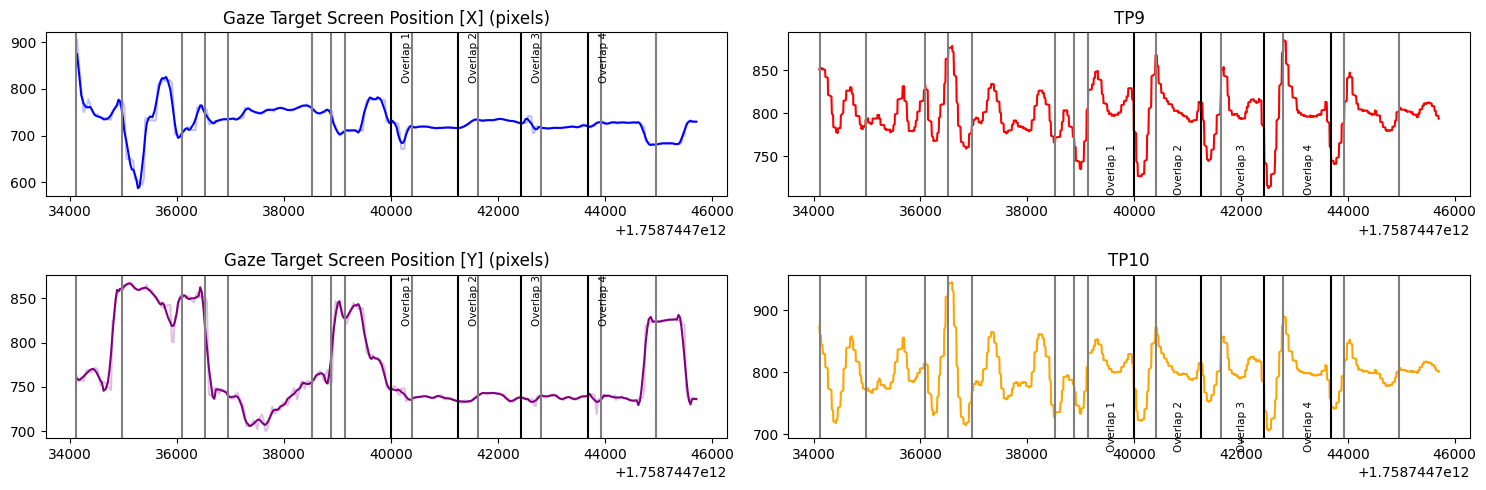

### Trial 2

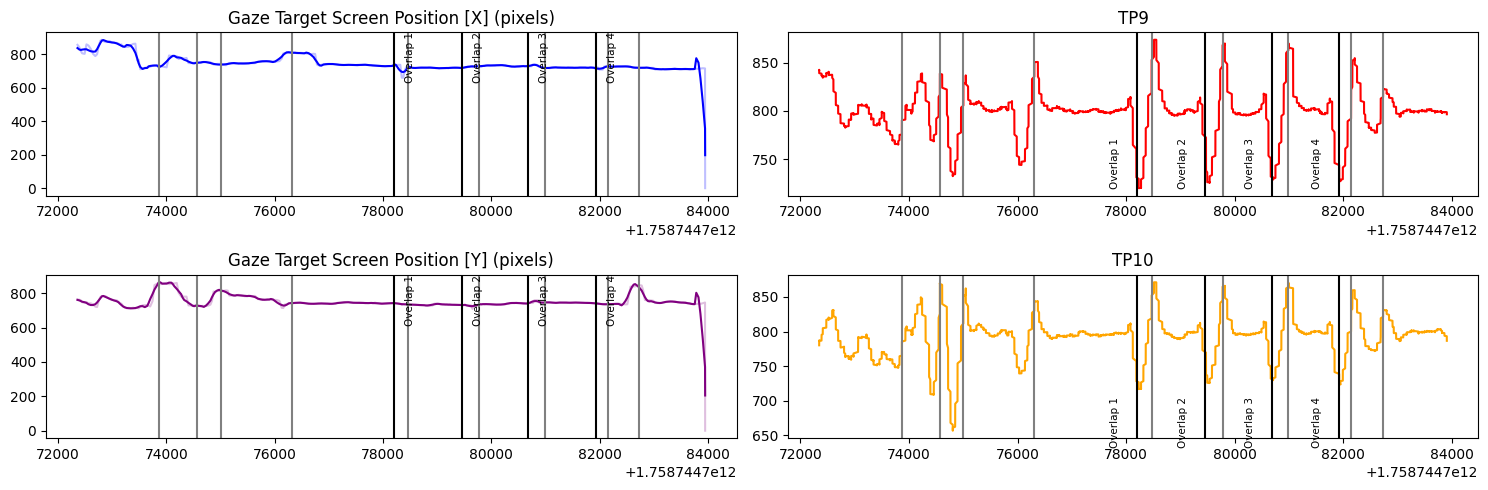

### Trial 3

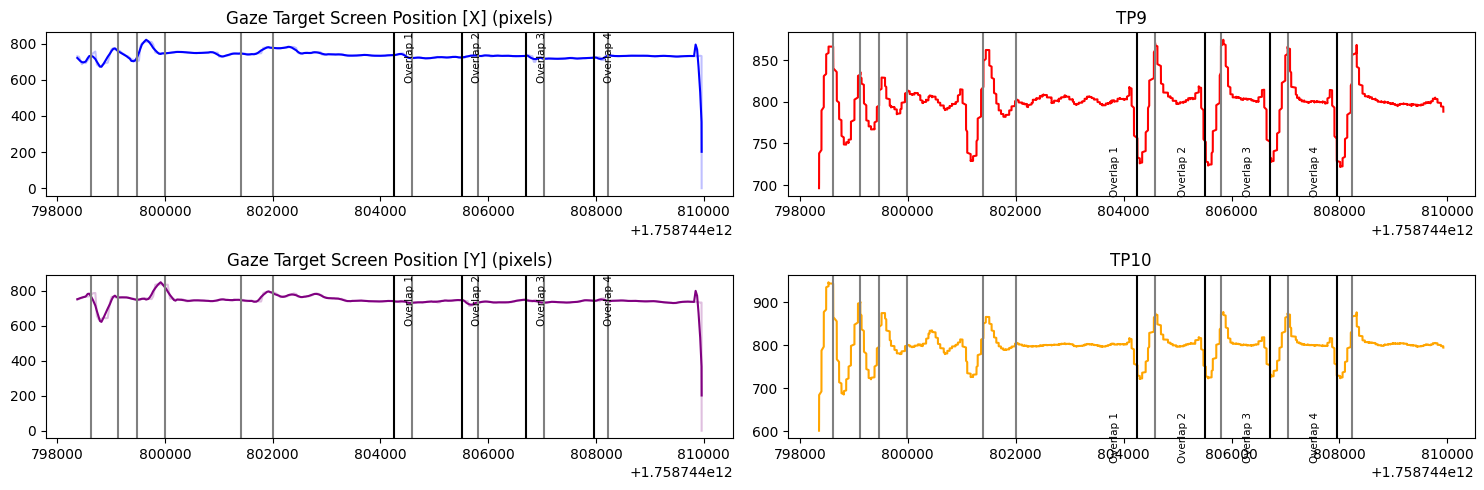

### Trial 4

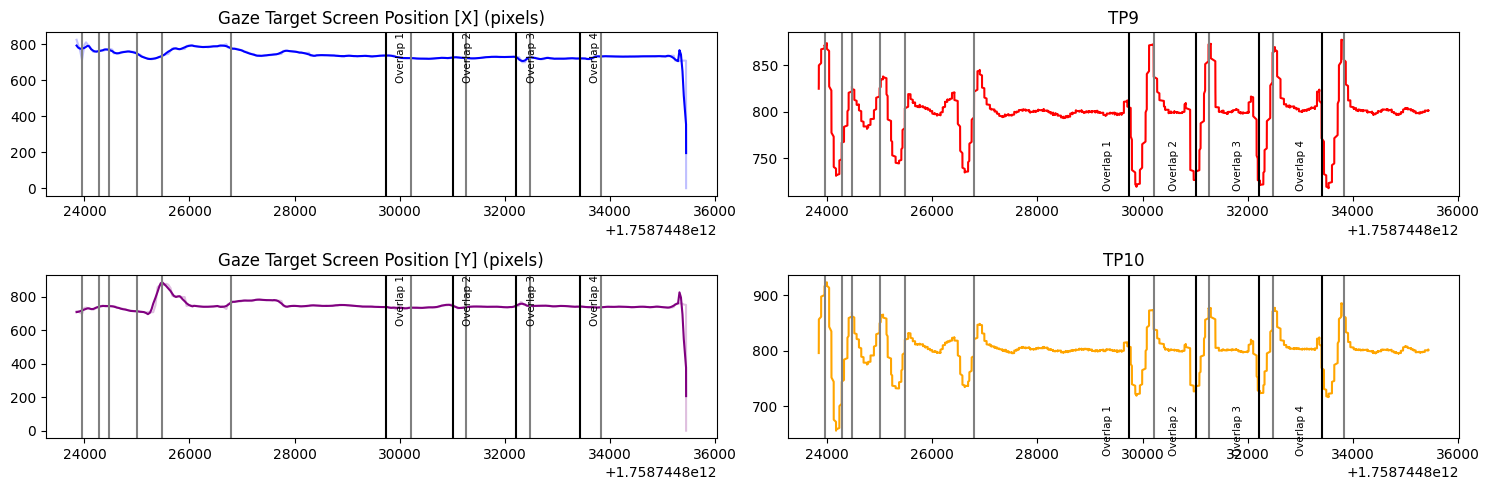

### Trial 5

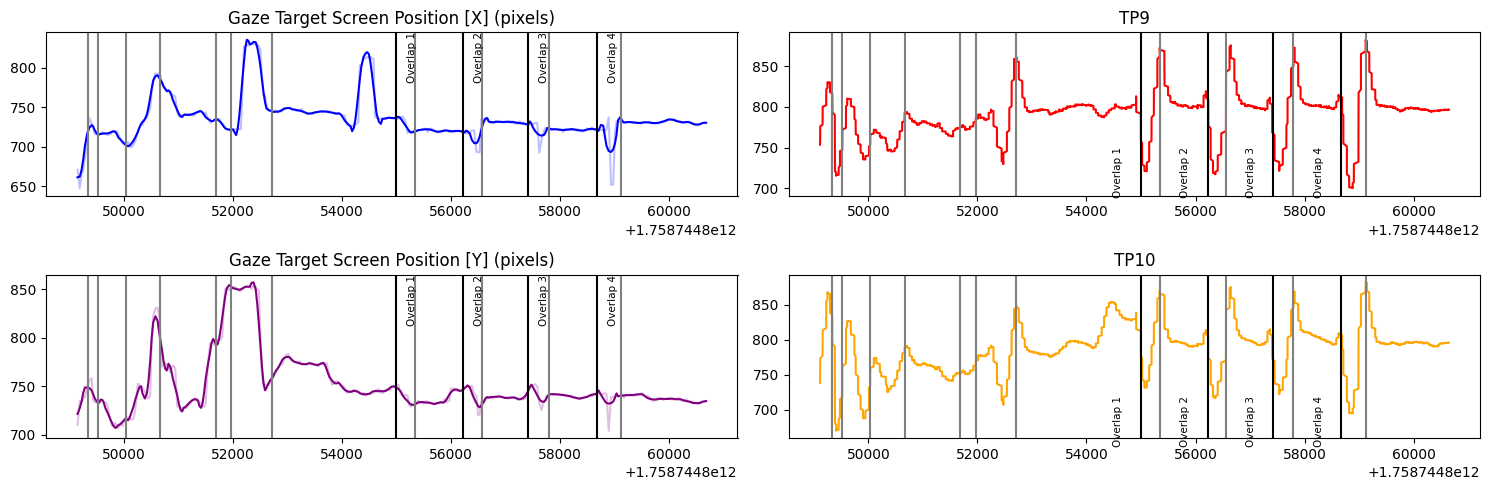

### Trial 6

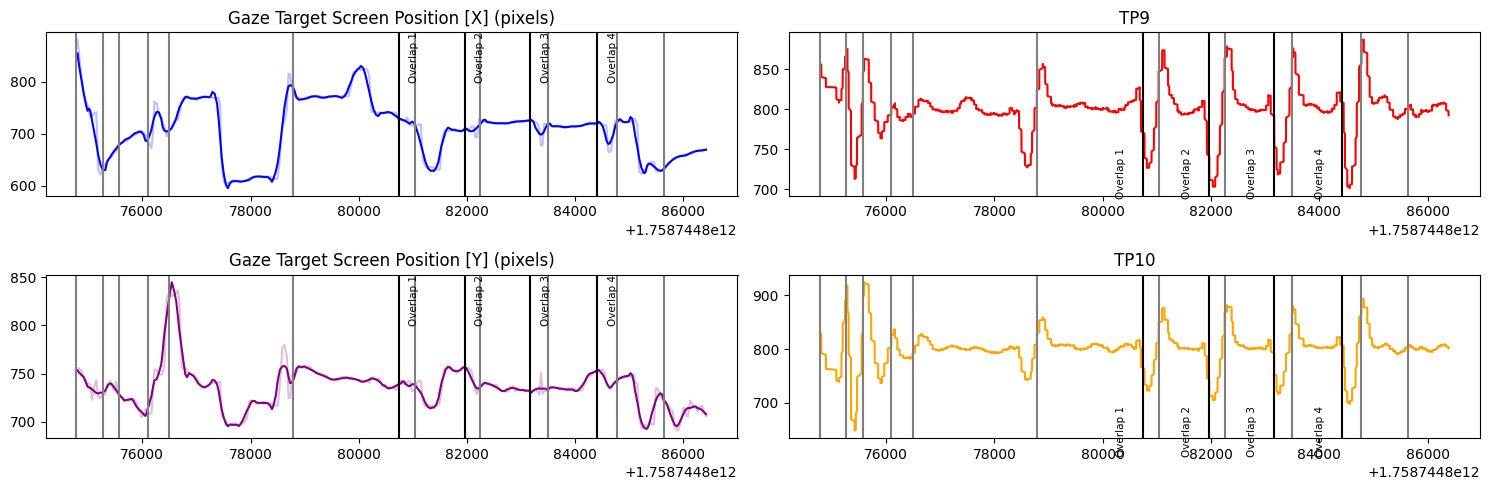

In [129]:
# Get all calibration sessions
all_cdfs = pd.read_csv('./data/P1/trials/calibrations.csv').drop(columns=['Unnamed: 0'])

# Iterate and operate on each calibration session of each trial
for index, trial in all_cdfs.iterrows():
    # What's the url to this calibration session?
    cal_dir = f'./data/P1/trials/{trial["trial_id"]}/calibration/'
    
    # get our data
    _eye = pd.read_csv(cal_dir+'eye.csv').drop(columns=['Unnamed: 0'])
    _eeg_raw = pd.read_csv(cal_dir+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
    _muse_blinks = pd.read_csv(cal_dir+'muse_blinks.csv').drop(columns=['Unnamed: 0'])
    _calibrations = pd.read_csv(cal_dir+'calibration.csv')
    _cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])

    # Graph in a 2x2. We use `plot_line` from one of the earlier code blocks to help us with this.
    # Define the fig and axes. We'll create a 1x3 graph for this one.
    fig, axes = plt.subplots(2,2, figsize=(15,5))

    # Render our charts
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_x'].to_list(), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_x'].to_list(), window_length=10, polyorder=3, mode='nearest'), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_y'].to_list(),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_y'].to_list(), window_length=10, polyorder=3, mode='nearest'),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP9'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[0][1],
        _color = 'red',
        _title = 'TP9',
        _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP10'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[1][1],
        _color = 'orange',
        _title = 'TP10',
        _marker=None
    )

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='black')
        axes[0][0].text(row['unix_ms']+200, axes[0][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][0].axvline(x=row['unix_ms'], c='black')
        axes[1][0].text(row['unix_ms']+200, axes[1][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[0][1].axvline(x=row['unix_ms'], c='black')
        axes[0][1].text(row['unix_ms']-500, axes[0][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][1].axvline(x=row['unix_ms'], c='black')
        axes[1][1].text(row['unix_ms']-500, axes[1][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    for index, row in _muse_blinks.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='gray')
        axes[1][0].axvline(x=row['unix_ms'], c='gray')
        axes[0][1].axvline(x=row['unix_ms'], c='gray')
        axes[1][1].axvline(x=row['unix_ms'], c='gray')

    display(Markdown(f'### Trial {trial["trial_id"]}'))
    plt.tight_layout()
    plt.show()

This gives us some crucial information about P1 in particular:

1. **Trials 5** appears to give a very good metric to identify blinks. It's the only one that's consistent, as the other trials have noisy data.
2. Optimal blink detection might involve 2nd-order or even 3rd-order analysis.

## Another Example: P4_Muse2

Let's look at another participant: P4_Muse2

### Trial 1

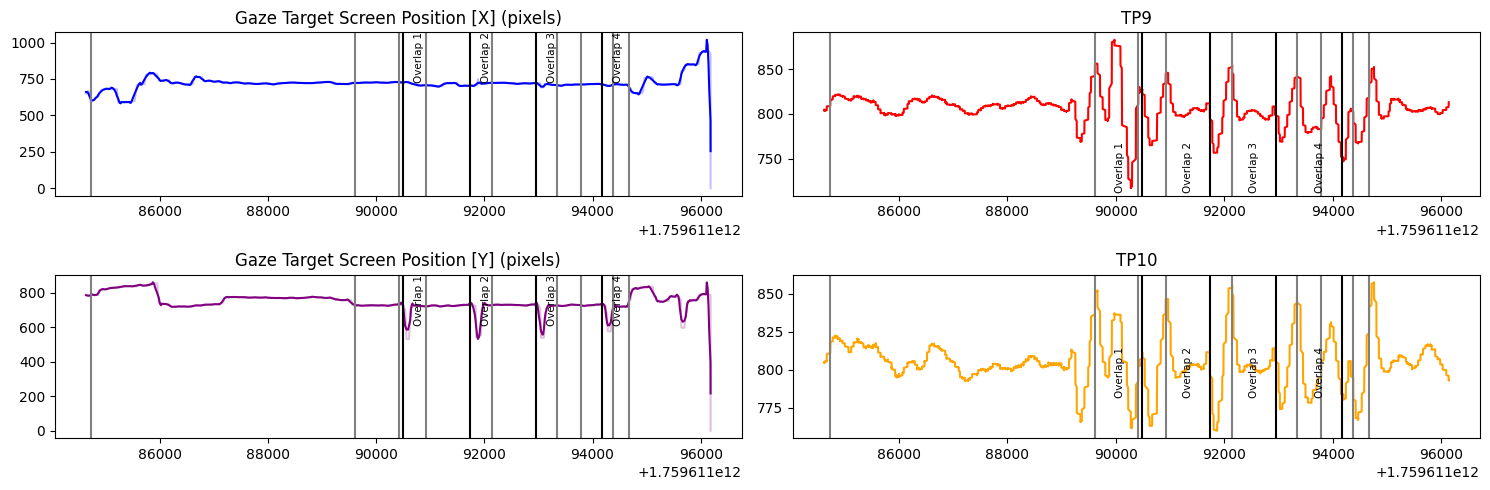

### Trial 2

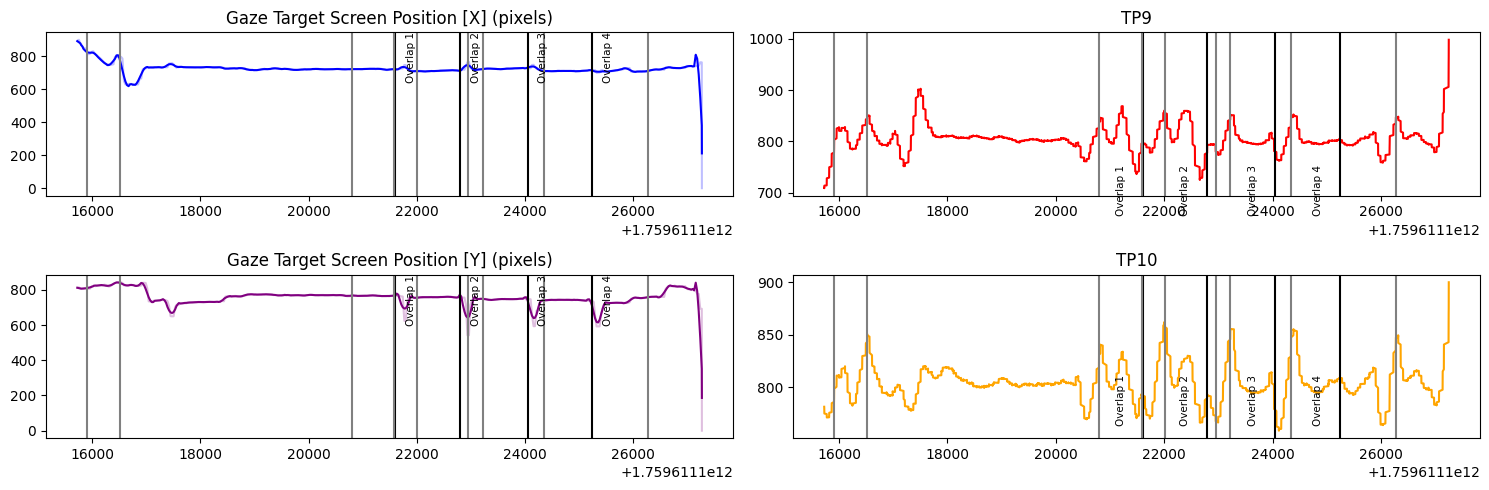

### Trial 3

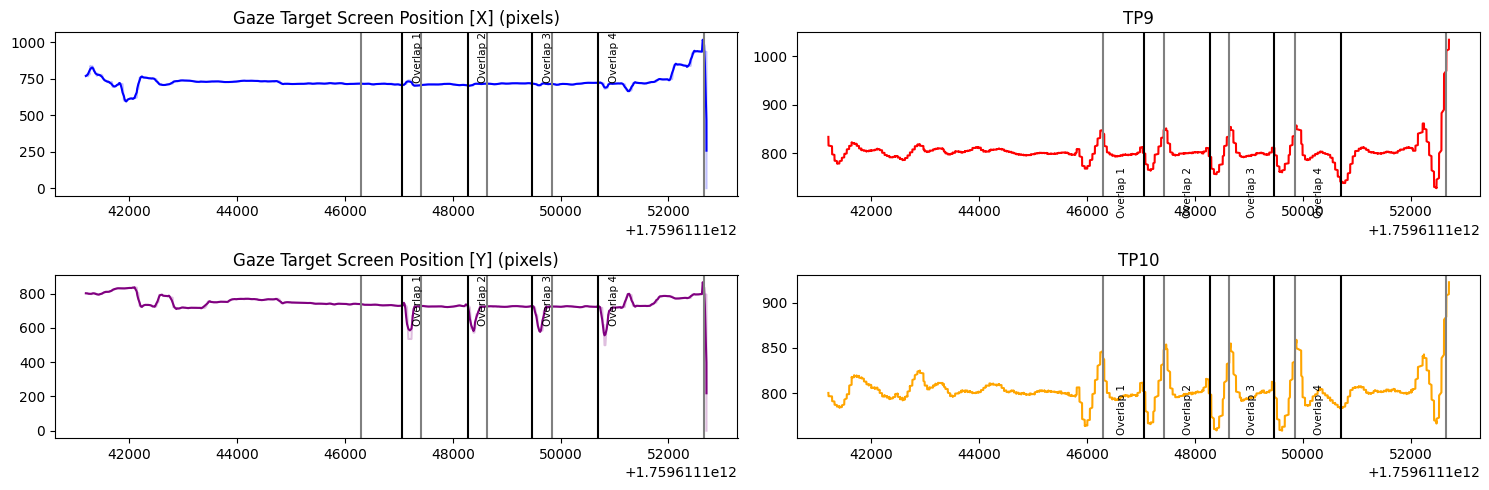

### Trial 4

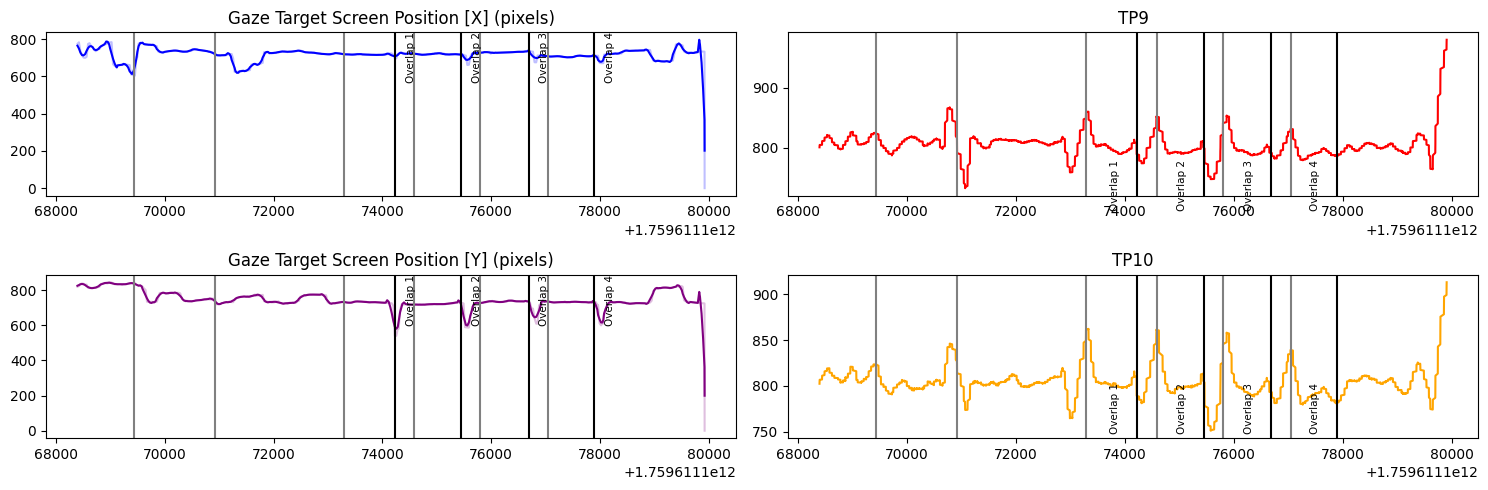

### Trial 5

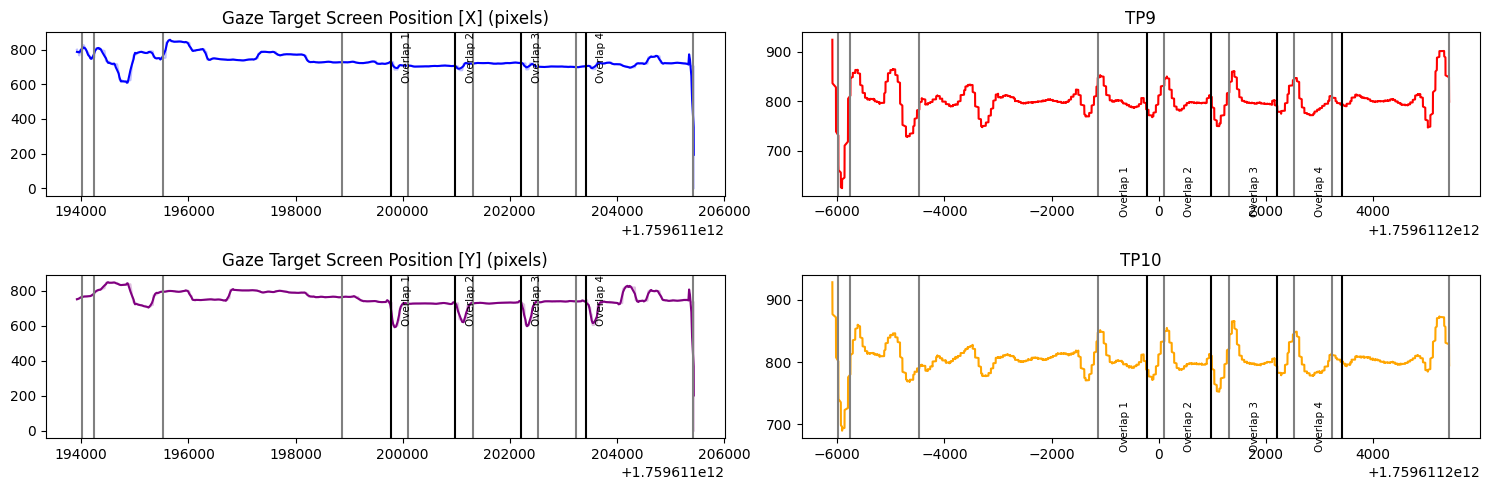

### Trial 6

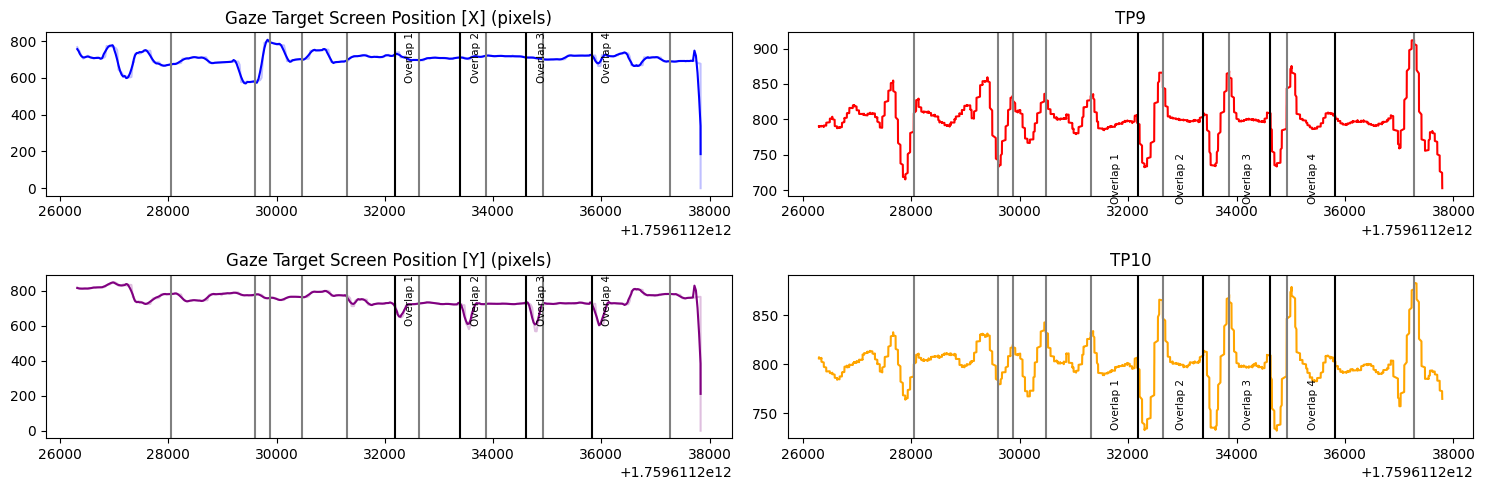

In [132]:
# Get all calibration sessions
all_cdfs = pd.read_csv('./data/P4_Muse2/trials/calibrations.csv').drop(columns=['Unnamed: 0'])

# Iterate and operate on each calibration session of each trial
for index, trial in all_cdfs.iterrows():
    # What's the url to this calibration session?
    cal_dir = f'./data/P4_Muse2/trials/{trial["trial_id"]}/calibration/'
    
    # get our data
    _eye = pd.read_csv(cal_dir+'eye.csv').drop(columns=['Unnamed: 0'])
    _eeg_raw = pd.read_csv(cal_dir+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
    _muse_blinks = pd.read_csv(cal_dir+'muse_blinks.csv').drop(columns=['Unnamed: 0'])
    _calibrations = pd.read_csv(cal_dir+'calibration.csv')
    _cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])

    # Graph in a 2x2. We use `plot_line` from one of the earlier code blocks to help us with this.
    # Define the fig and axes. We'll create a 1x3 graph for this one.
    fig, axes = plt.subplots(2,2, figsize=(15,5))

    # Render our charts
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_x'].to_list(), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_x'].to_list(), window_length=10, polyorder=3, mode='nearest'), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_y'].to_list(),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_y'].to_list(), window_length=10, polyorder=3, mode='nearest'),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP9'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[0][1],
        _color = 'red',
        _title = 'TP9',
        _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP10'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[1][1],
        _color = 'orange',
        _title = 'TP10',
        _marker=None
    )

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='black')
        axes[0][0].text(row['unix_ms']+200, axes[0][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][0].axvline(x=row['unix_ms'], c='black')
        axes[1][0].text(row['unix_ms']+200, axes[1][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[0][1].axvline(x=row['unix_ms'], c='black')
        axes[0][1].text(row['unix_ms']-500, axes[0][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][1].axvline(x=row['unix_ms'], c='black')
        axes[1][1].text(row['unix_ms']-500, axes[1][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    for index, row in _muse_blinks.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='gray')
        axes[1][0].axvline(x=row['unix_ms'], c='gray')
        axes[0][1].axvline(x=row['unix_ms'], c='gray')
        axes[1][1].axvline(x=row['unix_ms'], c='gray')

    display(Markdown(f'### Trial {trial["trial_id"]}'))
    plt.tight_layout()
    plt.show()

## Another-Another Example: P5

### Trial 1

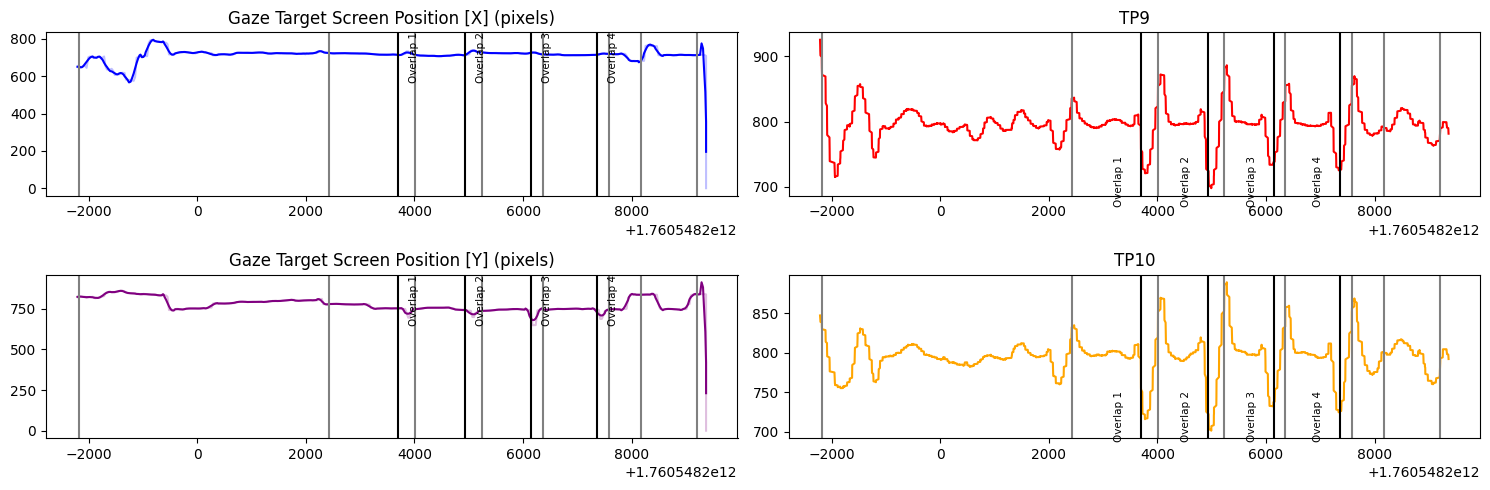

### Trial 2

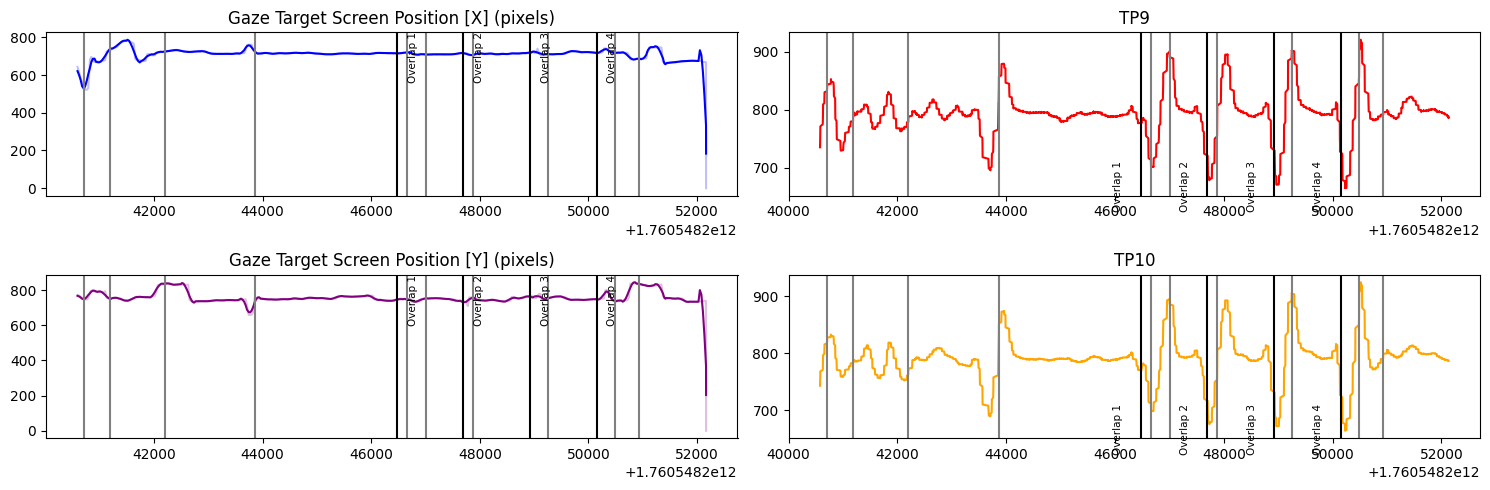

### Trial 3

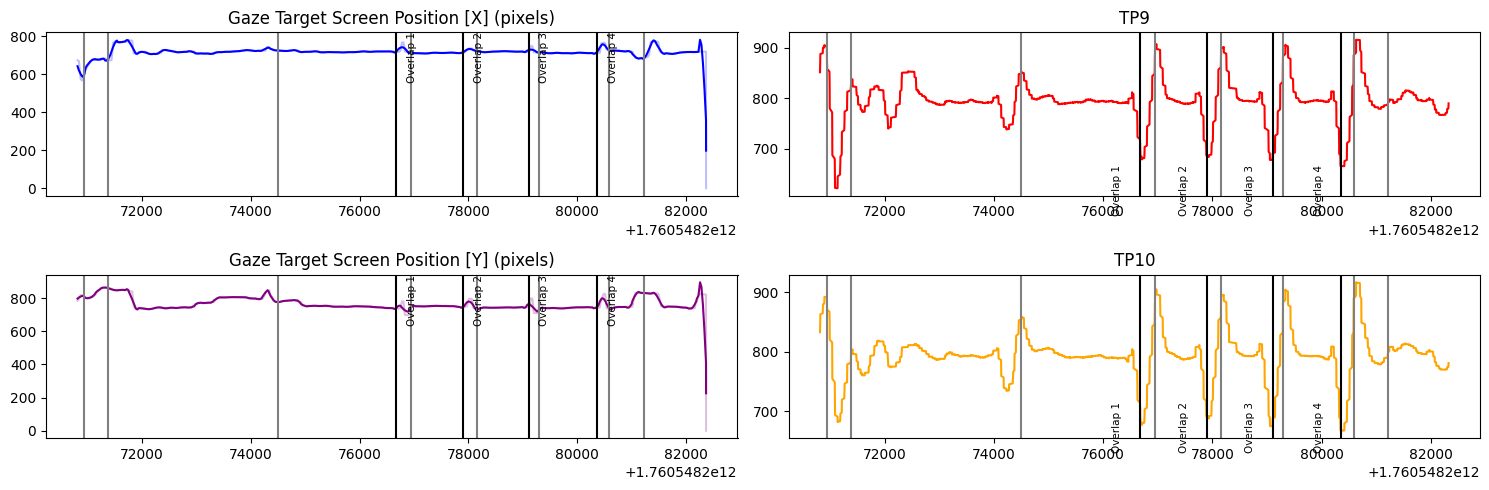

### Trial 4

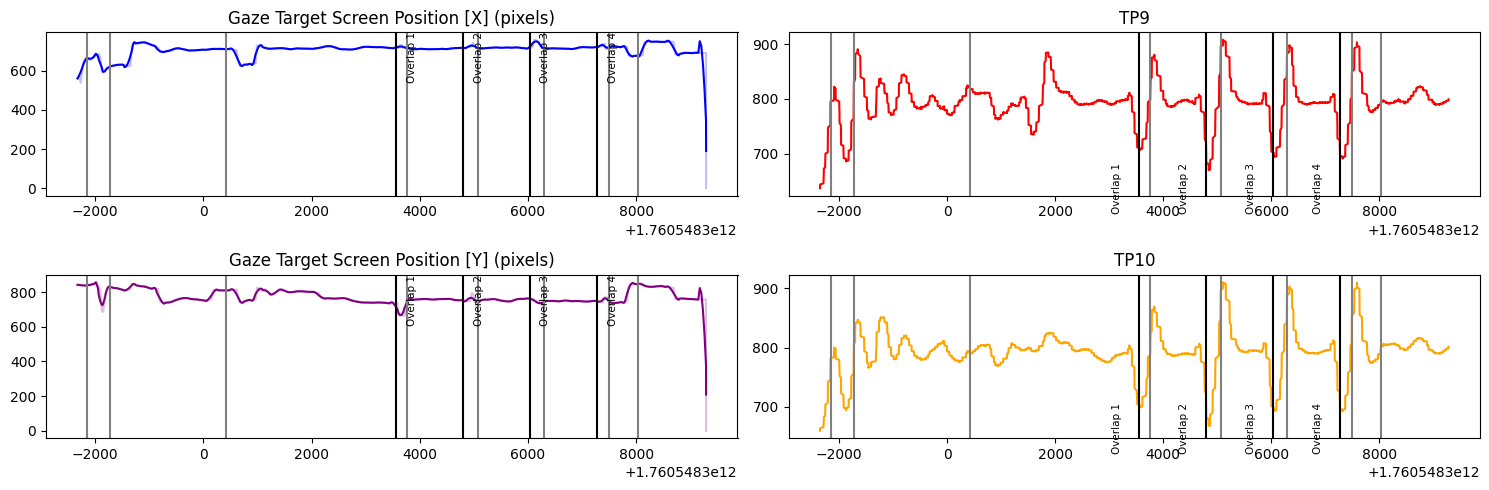

### Trial 5

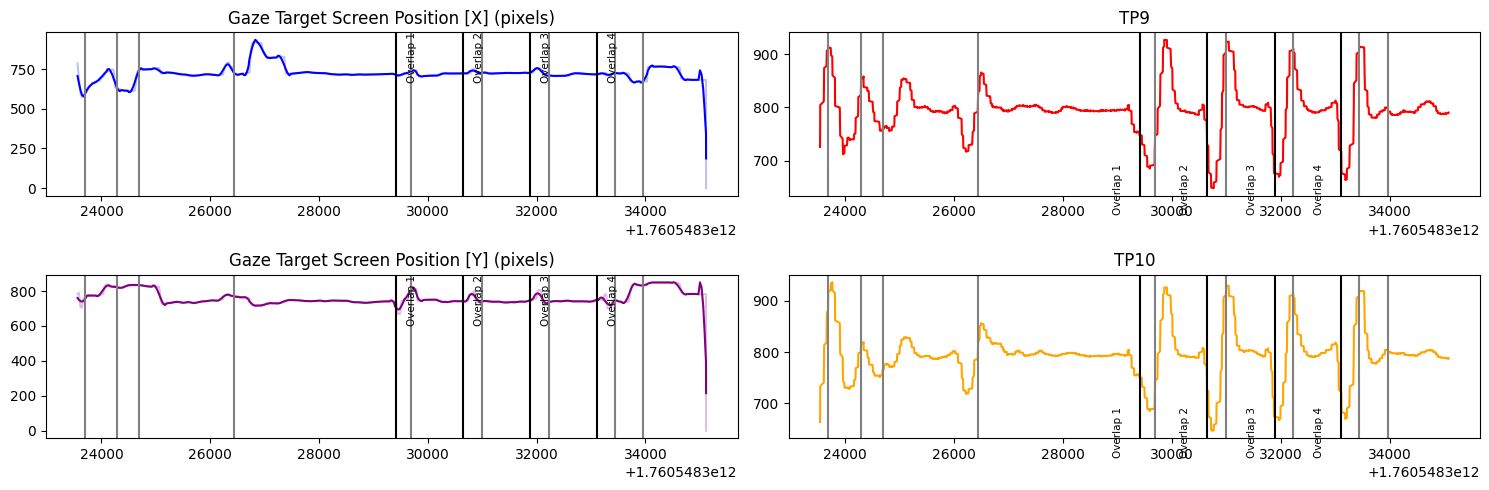

### Trial 6

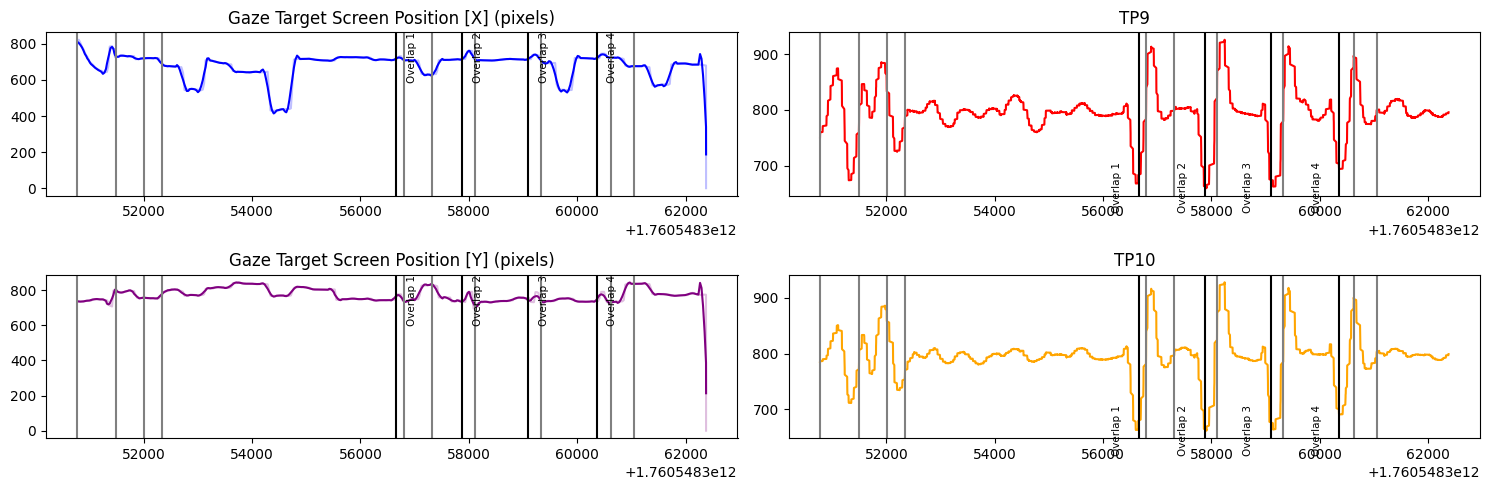

In [133]:
# Get all calibration sessions
all_cdfs = pd.read_csv('./data/P5/trials/calibrations.csv').drop(columns=['Unnamed: 0'])

# Iterate and operate on each calibration session of each trial
for index, trial in all_cdfs.iterrows():
    # What's the url to this calibration session?
    cal_dir = f'./data/P5/trials/{trial["trial_id"]}/calibration/'
    
    # get our data
    _eye = pd.read_csv(cal_dir+'eye.csv').drop(columns=['Unnamed: 0'])
    _eeg_raw = pd.read_csv(cal_dir+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
    _muse_blinks = pd.read_csv(cal_dir+'muse_blinks.csv').drop(columns=['Unnamed: 0'])
    _calibrations = pd.read_csv(cal_dir+'calibration.csv')
    _cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])

    # Graph in a 2x2. We use `plot_line` from one of the earlier code blocks to help us with this.
    # Define the fig and axes. We'll create a 1x3 graph for this one.
    fig, axes = plt.subplots(2,2, figsize=(15,5))

    # Render our charts
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_x'].to_list(), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_x'].to_list(), window_length=10, polyorder=3, mode='nearest'), 
        axes[0][0],
        _title =  'Gaze Target Screen Position [X] (pixels)', _color = 'blue', _marker=None
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        _eye['gaze_target_screen_pos_y'].to_list(),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None, _alpha=0.25
    )
    plot_line(
        _eye['unix_ms'].to_list(), 
        savgol_filter(_eye['gaze_target_screen_pos_y'].to_list(), window_length=10, polyorder=3, mode='nearest'),
        axes[1][0],
        _title =  'Gaze Target Screen Position [Y] (pixels)', _color = 'purple', _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP9'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[0][1],
        _color = 'red',
        _title = 'TP9',
        _marker=None
    )
    plot_line(
        _eeg_raw['unix_ms'].to_list(),
        savgol_filter(_eeg_raw['TP10'].to_list(), window_length=125, polyorder=3, mode='nearest'),
        axes[1][1],
        _color = 'orange',
        _title = 'TP10',
        _marker=None
    )

    # Render the calibration timestamps
    for index, row in _cdf.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='black')
        axes[0][0].text(row['unix_ms']+200, axes[0][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][0].axvline(x=row['unix_ms'], c='black')
        axes[1][0].text(row['unix_ms']+200, axes[1][0].get_ylim()[1]-0.05, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[0][1].axvline(x=row['unix_ms'], c='black')
        axes[0][1].text(row['unix_ms']-500, axes[0][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)
        axes[1][1].axvline(x=row['unix_ms'], c='black')
        axes[1][1].text(row['unix_ms']-500, axes[1][1].get_ylim()[0]+60, f"Overlap {row['overlap_counter']}", rotation=90, verticalalignment='top', fontsize=7.5)

    for index, row in _muse_blinks.iterrows():
        axes[0][0].axvline(x=row['unix_ms'], c='gray')
        axes[1][0].axvline(x=row['unix_ms'], c='gray')
        axes[0][1].axvline(x=row['unix_ms'], c='gray')
        axes[1][1].axvline(x=row['unix_ms'], c='gray')

    display(Markdown(f'### Trial {trial["trial_id"]}'))
    plt.tight_layout()
    plt.show()

## Learning points from P1, P4_Muse2, and P5

- There's a LOT of variability. Honestly, a LOT of it.
- This might require a manual process where, for each participant, we need to identify 1) what trials are even viable, and 2) from those viable trials, measure the difference in the fluctuation of the EEG signal from the fluctuation in the eye data.

The interesting thing is that we may need some form of either:

- **Template Matching**: since the EEG follows a consistent pattern of normal => valley => peak => normal, can we use some form of template matching? We'll have to account for variations in the pattern though..
- **1st-Order or 2nd-Order Derivatives**: We look at the first derivative to identify when a transition in the change of the signal occurs. I.e. upon moving to the valley, the velocity is negative; then it instantly transforms into a positive sign when moving to the peak, then it transitions to the negative sign again when moving to the normal value.

Let's try the 1st-Order analysis for now.

### 1st Order: P1

Let's look at P1's Trial 5, which contains a relatively stable eye tracking change during the calibration phase. The idea now is to look at TP9 and TP10, measure its 1st-order derivative, and track the sign changes.

In [ ]:
import numpy as np

# Same as before
_EX_DIR = './data/P1/trials/1/calibration/'
_eye = pd.read_csv(_EX_DIR+'eye.csv').drop(columns=['Unnamed: 0'])
_muse_blinks = pd.read_csv(_EX_DIR+'muse_blinks.csv').drop(columns=['Unnamed: 0'])
_eeg_raw = pd.read_csv(_EX_DIR+'eeg_raw.csv').drop(columns=['Unnamed: 0'])
_calibrations = pd.read_csv(_EX_DIR+'calibration.csv')
_cdf = _calibrations[_calibrations['event'] == 'Overlap'].drop(columns=['Unnamed: 0', 'rel_timestamp', 'event'])

# We make sure to handle duplicates by finding the mean values of them
_eeg_raw2 = _eeg_raw.groupby('unix_ms', as_index=False).mean()

# now extract X
x = np.array(_eeg_raw2['unix_ms'].to_list())

def update_plot(wl1=125, po1=3, wl2=125, po2=3):

        # Now extract TP9, TP10
        y1 = _eeg_raw2['TP9'].to_list()
        y2 = _eeg_raw2['TP10'].to_list()
        tp9 = np.array(savgol_filter(y1, window_length=wl1, polyorder=po1, mode='nearest'))
        tp10 = np.array(savgol_filter(y2, window_length=wl1, polyorder=po1, mode='nearest'))

        # Double-check duplicates for x
        duplicates = np.where(np.diff(x) == 0)[0]
        if len(duplicates) > 0:
                print("Duplicates found!", duplicates, file=sys.stderr)

        # Calculate 1st order derivatives
        tp9_dy = np.diff(tp9) / np.diff(x)
        tp10_dy = np.diff(tp10) / np.diff(x)
        tp9_dy = np.append(tp9_dy, 0)
        tp10_dy = np.append(tp10_dy, 0)

        tp9_dy_smoothed = np.array(savgol_filter(tp9_dy, window_length=wl2, polyorder=po2, mode='nearest'))
        tp10_dy_smoothed = np.array(savgol_filter(tp10_dy, window_length=wl2, polyorder=po2, mode='nearest'))

        # Plot
        # Graph in a 2x2. We use `plot_line` from one of the earlier code blocks to help us with this.
        # Define the fig and axes. We'll create a 1x3 graph for this one.
        fig, axes = plt.subplots(4,1, figsize=(15,10))

        # Render our charts
        plot_line(x, y1, axes[0], _color = 'red', _title = 'TP9', _marker=None, _alpha=0.25)
        plot_line(x, tp9, axes[0], _color = 'red', _title = 'TP9', _marker=None)
        plot_line(x, tp9_dy, axes[1], _color = 'red', _title = 'TP9 - 1st-Order Deriv.', _marker=None, _alpha=0.25)
        plot_line(x, tp9_dy_smoothed, axes[1], _color = 'red', _title = 'TP9 - 1st-Order Deriv.', _marker=None)
        plot_line(x, y2, axes[2], _color = 'orange', _title = 'TP10', _marker=None, _alpha=0.25)
        plot_line(x, tp10, axes[2], _color = 'orange', _title = 'TP10', _marker=None)
        plot_line(x, tp10_dy, axes[3], _color = 'orange', _title = 'TP10 - 1st-Order Deriv.', _marker=None, _alpha=0.25)
        plot_line(x, tp10_dy_smoothed, axes[3], _color = 'orange', _title = 'TP10 - 1st-Order Deriv.', _marker=None)


        # Render the calibration timestamps
        for index, row in _cdf.iterrows():
                axes[0].axvline(x=row['unix_ms'], c='black')
                axes[1].axvline(x=row['unix_ms'], c='black')
                axes[2].axvline(x=row['unix_ms'], c='black')
                axes[3].axvline(x=row['unix_ms'], c='black')
        for index, row in _muse_blinks.iterrows():
                axes[0].axvline(x=row['unix_ms'], c='magenta')
                axes[1].axvline(x=row['unix_ms'], c='magenta')
                axes[2].axvline(x=row['unix_ms'], c='magenta')
                axes[3].axvline(x=row['unix_ms'], c='magenta')

        plt.tight_layout()
        plt.show()

interact(
    update_plot,
    wl1 = FloatSlider(value=125, min=10, max=250, step=0.1, description='Window Length'),
    po1 = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order'),
    wl2 = FloatSlider(value=125, min=10, max=250, step=0.1, description='Window Length'),
    po2 = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order')
)

interactive(children=(FloatSlider(value=125.0, description='Window Length', max=250.0, min=10.0), IntSlider(va…

<function __main__.update_plot(wl1=125, po1=3, wl2=125, po2=3)>

This is a pretty intersting idea where we're also smoothing the 1st-order derivative. The smoothing allows us to remove issues caused by stepping in the already-smoothed TP9 and TP10 data. Not ideal, but it's the closest we'll get honestly.

The next step would be, for each known overlap, we record the time interval between the overlap (black line) and its following muse-detected blink (magenta line). As long as we can record the moment in time when the velocity of the signal reaches its peak, then that's the moment when the 